In [23]:
import os
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/alzheimer_project"
os.makedirs(PROJECT_DIR, exist_ok=True)
print("Project dir:", PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project dir: /content/drive/MyDrive/alzheimer_project


In [24]:
import os, json
import torch
import torch.nn as nn
from torchvision import models

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROJECT_DIR = "/content/drive/MyDrive/alzheimer_project"
os.makedirs(PROJECT_DIR, exist_ok=True)

# Hardcode mapping (same as CNN notebook)
CLASS_NAMES  = ["Dementia", "Non Demented", "Very mild Dementia"]
CLASS_TO_IDX = {"Dementia": 0, "Non Demented": 1, "Very mild Dementia": 2}
LABEL_MERGE  = {
    "Mild Dementia":      "Dementia",
    "Moderate Dementia":  "Dementia",
    "Very mild Dementia": "Very mild Dementia",
    "Non Demented":       "Non Demented",
}

# Save it now so future notebooks can load it
mapping = {"CLASS_NAMES": CLASS_NAMES, "CLASS_TO_IDX": CLASS_TO_IDX, "LABEL_MERGE": LABEL_MERGE}
with open(f"{PROJECT_DIR}/class_mapping.json", "w") as f:
    json.dump(mapping, f, indent=2)

# Rebuild and load model
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 3)
model.load_state_dict(
    torch.load(f"{PROJECT_DIR}/best_resnet18.pth", map_location=DEVICE)
)
model = model.to(DEVICE)
model.eval()

print("Done. Recovered from Drive.")
print("class_mapping.json saved for future notebooks.")

Done. Recovered from Drive.
class_mapping.json saved for future notebooks.


In [25]:
!pip install -q kaggle

In [26]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_283606f7db27511d5bedbdc1c43c0695"

In [27]:
!kaggle datasets list -s oasis

ref                                                            title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  -----------------------------------------------  ------------  --------------------------  -------------  ---------  ---------------  
ninadaithal/imagesoasis                                        OASIS Alzheimer's Detection                        1322017985  2023-06-18 13:23:08.663000          26351        162  0.875            
federicoseijo/oasis-discography                                Oasis discography                                       39039  2021-09-25 13:02:59.570000            286         16  0.9411765        
jboysen/mri-and-alzheimers                                     MRI and Alzheimers                                      12924  2017-08-16 17:18:10.663000          39328        556  0.85294116       
shreyanmoh

In [28]:
!kaggle datasets download -d ninadaithal/imagesoasis

Dataset URL: https://www.kaggle.com/datasets/ninadaithal/imagesoasis
License(s): apache-2.0
100% 1.23G/1.23G [00:14<00:00, 91.6MB/s]



In [29]:
!unzip -q imagesoasis.zip -d MRI_DATA

In [30]:
import os

for folder in os.listdir("MRI_DATA"):
    print(folder)

Data


In [31]:
from torchvision.datasets import ImageFolder

dataset = ImageFolder(
    root="MRI_DATA/Data"
)

print(dataset.classes)
print(len(dataset))

['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
86437


In [32]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.utils.class_weight import compute_class_weight

In [33]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

Device: cuda


In [34]:
DATA_DIR = "/content/MRI_DATA/Data"

In [35]:
all_records = []

subject_pattern = re.compile(r"(OAS\d+_\d+)", re.IGNORECASE)

# Label-merge map: collapse Mild + Moderate → "Dementia"
LABEL_MERGE = {
    "Mild Dementia":     "Dementia",
    "Moderate Dementia": "Dementia",
    "Very mild Dementia":"Very mild Dementia",
    "Non Demented":      "Non Demented",
}

for class_name in os.listdir(DATA_DIR):

    class_path = os.path.join(
        DATA_DIR,
        class_name
    )

    if not os.path.isdir(class_path):
        continue

    merged_label = LABEL_MERGE.get(class_name, class_name)

    for fname in os.listdir(class_path):

        fpath = os.path.join(
            class_path,
            fname
        )

        match = subject_pattern.search(fname)

        if match:
            subject_id = match.group(1)
        else:
            subject_id = fname

        all_records.append({
            "subject_id": subject_id,
            "image_path": fpath,
            "label": merged_label
        })

inventory_df = pd.DataFrame(all_records)

print(inventory_df.shape)

inventory_df.head()


(86437, 3)


,subject_id,image_path,label
0,OAS1_0351,/content/MRI_DATA/Data/Moderate Dementia/OAS1_...,Dementia
1,OAS1_0308,/content/MRI_DATA/Data/Moderate Dementia/OAS1_...,Dementia
2,OAS1_0351,/content/MRI_DATA/Data/Moderate Dementia/OAS1_...,Dementia
3,OAS1_0351,/content/MRI_DATA/Data/Moderate Dementia/OAS1_...,Dementia
4,OAS1_0351,/content/MRI_DATA/Data/Moderate Dementia/OAS1_...,Dementia


In [36]:
#SUBJECT DISTRIBUTION
print(
    "Unique Subjects:",
    inventory_df["subject_id"].nunique()
)

inventory_df["label"].value_counts()

Unique Subjects: 347


,count
label,
Non Demented,67222
Very mild Dementia,13725
Dementia,5490


In [37]:
subject_df = (
    inventory_df
    .groupby("subject_id")
    .first()
    .reset_index()
)

train_subjects, temp_subjects = train_test_split(
    subject_df,
    test_size=0.30,
    random_state=SEED,
    shuffle=True
)

val_subjects, test_subjects = train_test_split(
    temp_subjects,
    test_size=0.50,
    random_state=SEED,
    shuffle=True
)

train_ids = set(train_subjects["subject_id"])
val_ids = set(val_subjects["subject_id"])
test_ids = set(test_subjects["subject_id"])

train_df = inventory_df[
    inventory_df["subject_id"].isin(train_ids)
]

val_df = inventory_df[
    inventory_df["subject_id"].isin(val_ids)
]

test_df = inventory_df[
    inventory_df["subject_id"].isin(test_ids)
]

print("Train images:", len(train_df))
print("Val images:", len(val_df))
print("Test images:", len(test_df))

print("Train subjects:", len(train_ids))
print("Val subjects:", len(val_ids))
print("Test subjects:", len(test_ids))

Train images: 59414
Val images: 12627
Test images: 14396
Train subjects: 242
Val subjects: 52
Test subjects: 53


In [38]:
# NOTE: augmentation defined in the next cell (cell 14)


In [39]:
# MRI-appropriate augmentation
# - Horizontal flip: anatomically plausible for brain MRI slices
# - Small rotation (≤10°): accounts for head tilt variation
# - Small translate (5%) + scale (±5%): simulates positioning differences
# - No vertical flip / color jitter / strong distortions (unrealistic for MRI)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [40]:
# Single consistent 3-class mapping used across train / val / test
CLASS_NAMES = [
    "Dementia",          # merged: Mild + Moderate Dementia
    "Non Demented",
    "Very mild Dementia",
]

CLASS_TO_IDX = {
    cls: idx
    for idx, cls in enumerate(CLASS_NAMES)
}

IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

print("Class mapping:", CLASS_TO_IDX)


Class mapping: {'Dementia': 0, 'Non Demented': 1, 'Very mild Dementia': 2}


In [41]:
#dataset class
class MRIDataset(Dataset):

    def __init__(self, dataframe, transform):

        self.df = dataframe.reset_index(drop=True)

        self.transform = transform

        self.class_to_idx = CLASS_TO_IDX
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        image = self.transform(image)

        label = self.class_to_idx[
            row["label"]
        ]

        return image, label

In [42]:
# Dataset objects
train_dataset = MRIDataset(train_df, train_transform)
val_dataset   = MRIDataset(val_df,   test_transform)
test_dataset  = MRIDataset(test_df,  test_transform)


In [43]:
from torch.utils.data import WeightedRandomSampler

# Per-sample weights based on merged labels
class_counts = train_df["label"].value_counts()
weights_per_class = {
    cls: 1.0 / count
    for cls, count in class_counts.items()
}
sample_weights = train_df["label"].map(weights_per_class).values

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,      # replaces shuffle=True
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)


In [44]:
model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    3          # 3 classes: Dementia / Non Demented / Very mild Dementia
)

model = model.to(DEVICE)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 113MB/s]


In [45]:
from sklearn.metrics import f1_score

# Class weights on merged training labels
labels_train = train_df["label"]
classes      = np.array(CLASS_NAMES)  # use global consistent order

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=labels_train
)

weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
print("Class weights:", dict(zip(CLASS_NAMES, weights.cpu().numpy())))

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

# ReduceLROnPlateau: cuts LR when val Macro-F1 stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",       # maximising F1
    factor=0.5,       # halve LR on plateau
    patience=2,
)


Class weights: {'Dementia': np.float32(4.8457713), 'Non Demented': np.float32(0.43814665), 'Very mild Dementia': np.float32(1.9558233)}


In [46]:
EPOCHS = 10

best_val_f1 = 0.0   # track Macro-F1 instead of accuracy

train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []
val_f1s      = []


In [47]:
def evaluate(loader):
    model.eval()

    loss_sum = 0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss_sum += loss.item()

            preds = outputs.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc      = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return loss_sum / len(loader), acc, macro_f1


In [48]:
for epoch in range(EPOCHS):
    model.train()

    running_loss = 0
    correct = 0
    total   = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds    = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc  = correct / total

    val_loss, val_acc, val_f1 = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)

    # Step LR scheduler on Macro-F1
    scheduler.step(val_f1)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss={train_loss:.4f} Acc={train_acc:.4f} | "
        f"Val Loss={val_loss:.4f} Acc={val_acc:.4f} Macro-F1={val_f1:.4f}"
    )

    # Save best model by Macro-F1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), f"{PROJECT_DIR}/best_resnet18.pth")
        print(f"  → Best model saved (Macro-F1={best_val_f1:.4f})")


Epoch 1/10 | Train Loss=0.1566 Acc=0.8701 | Val Loss=0.8779 Acc=0.7131 Macro-F1=0.4559
  → Best model saved (Macro-F1=0.4559)
Epoch 2/10 | Train Loss=0.0507 Acc=0.9512 | Val Loss=0.7161 Acc=0.7805 Macro-F1=0.5229
  → Best model saved (Macro-F1=0.5229)
Epoch 3/10 | Train Loss=0.0294 Acc=0.9719 | Val Loss=0.9472 Acc=0.8094 Macro-F1=0.4794
Epoch 4/10 | Train Loss=0.0216 Acc=0.9794 | Val Loss=0.9601 Acc=0.7945 Macro-F1=0.5175
Epoch 5/10 | Train Loss=0.0189 Acc=0.9840 | Val Loss=0.9048 Acc=0.8199 Macro-F1=0.5021
Epoch 6/10 | Train Loss=0.0038 Acc=0.9964 | Val Loss=1.0278 Acc=0.8064 Macro-F1=0.4745
Epoch 7/10 | Train Loss=0.0056 Acc=0.9948 | Val Loss=1.2497 Acc=0.7933 Macro-F1=0.4996
Epoch 8/10 | Train Loss=0.0042 Acc=0.9962 | Val Loss=1.2394 Acc=0.8080 Macro-F1=0.4805
Epoch 9/10 | Train Loss=0.0016 Acc=0.9986 | Val Loss=1.0943 Acc=0.8292 Macro-F1=0.5010
Epoch 10/10 | Train Loss=0.0014 Acc=0.9986 | Val Loss=1.1821 Acc=0.8380 Macro-F1=0.4506


In [49]:
# Load the best checkpoint saved during training
model.load_state_dict(
    torch.load(f"{PROJECT_DIR}/best_resnet18.pth", map_location=DEVICE)
)
model.eval()
print("Loaded best model from Drive")

Loaded best model from Drive


In [52]:
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        preds   = outputs.argmax(1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(f"Collected {len(y_true)} predictions")

Collected 14396 predictions


In [53]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES
    )
)

# Macro-F1 and per-class recall (the metrics we optimised for)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
print(f"Test Macro-F1: {macro_f1:.4f}")


                    precision    recall  f1-score   support

          Dementia       0.37      0.57      0.45       671
      Non Demented       0.92      0.93      0.93     11346
Very mild Dementia       0.73      0.60      0.66      2379

          accuracy                           0.86     14396
         macro avg       0.68      0.70      0.68     14396
      weighted avg       0.87      0.86      0.86     14396

Test Macro-F1: 0.6786


Class mapping consistent across splits: {'Dementia': 0, 'Non Demented': 1, 'Very mild Dementia': 2}


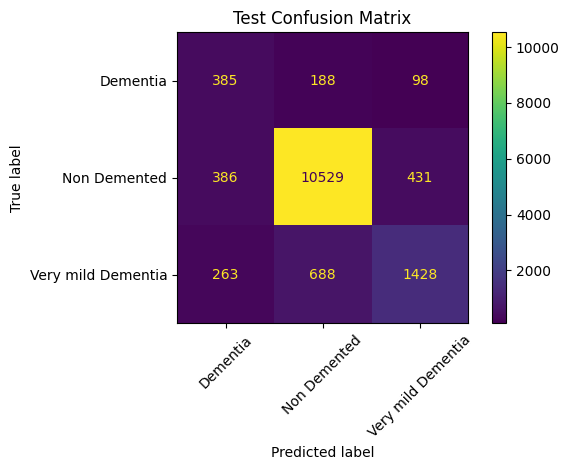

In [54]:
# Verify all splits use identical mapping
assert train_dataset.class_to_idx == val_dataset.class_to_idx == test_dataset.class_to_idx == CLASS_TO_IDX
print("Class mapping consistent across splits:", CLASS_TO_IDX)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(xticks_rotation=45)
plt.title("Test Confusion Matrix")
plt.tight_layout()
plt.show()


In [55]:
print(test_df["label"].value_counts())

label
Non Demented          11346
Very mild Dementia     2379
Dementia                671
Name: count, dtype: int64


In [56]:
import json

# Save class mapping so embedding notebook doesn't hardcode it
mapping = {
    "CLASS_NAMES":  CLASS_NAMES,
    "CLASS_TO_IDX": CLASS_TO_IDX,
    "LABEL_MERGE":  LABEL_MERGE
}
with open(f"{PROJECT_DIR}/class_mapping.json", "w") as f:
    json.dump(mapping, f, indent=2)

print("Saved to Drive:")
print(f"  {PROJECT_DIR}/best_resnet18.pth")
print(f"  {PROJECT_DIR}/class_mapping.json")

Saved to Drive:
  /content/drive/MyDrive/alzheimer_project/best_resnet18.pth
  /content/drive/MyDrive/alzheimer_project/class_mapping.json
